# <B><I><U>stress_model_building</U> ----</B></I>

In [1]:
# IGNORE WARNING --

import warnings

warnings.filterwarnings("ignore")

In [2]:
# IMPORTING ALL NECESSARY LIBRARIES --

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

print("ALL NECESSARY LIBRARIES ARE IMPORTED SUCESSFULLY:")
print("🎉🎉🎉🎉")

ALL NECESSARY LIBRARIES ARE IMPORTED SUCESSFULLY:
🎉🎉🎉🎉


In [3]:
# loading dataset --

BASE_DIR = Path.cwd().parent

df = pd.read_csv(
    BASE_DIR /
    "preprocessed" /
    "stress_cleaned.csv"
)

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,peer_pressure,extracurricular_activities,bullying,stress_level,mental_health_score,academic_stress_score,environment_score,physical_health_score,support_score,risk_score
0,14,20,0,11,2,1,2,4,2,3,...,3,3,2,1,25,7,6,7,5,38
1,15,8,1,15,5,3,1,4,3,1,...,4,5,5,2,30,13,10,12,2,53
2,12,18,1,14,2,1,2,2,2,2,...,3,2,2,1,26,8,7,5,5,41
3,16,12,1,15,4,3,1,3,4,2,...,4,4,5,2,31,11,10,10,2,52
4,16,28,0,7,2,3,5,1,3,2,...,5,0,5,1,23,6,7,6,2,36


In [4]:
# checking shape --

print(df.shape)

(1100, 27)


In [5]:
# DEFINING TARGET --

TARGET = "stress_level"

In [6]:
# REMOVE DERIVED FEATURES --

drop_cols = [

    "stress_level",

    "risk_score",

    "academic_stress_score",

    "mental_health_score",

    "environment_score",

    "physical_health_score",

    "support_score"
]

In [7]:
#DEFINING DATA -- 

X = df.drop(
    columns=drop_cols
)

y = df[TARGET]

In [8]:
# CHECKIN SHAPE --

print(y.shape)

print(X.shape)

(1100,)
(1100, 20)


In [9]:
# TRAIN TEST SPLIT --

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y
    )
)

In [10]:
# VERIFY SPLIT --

print(X_train.shape)
print(X_test.shape)

(880, 20)
(220, 20)


In [11]:
# RANDOM FOREST --

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [12]:
# PREDICTION --

y_pred = rf.predict(
    X_test
)

In [13]:
# ACCURACY --

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

Accuracy: 88.64 %


In [14]:
# CLASSIFICATION REORT --

print(

    classification_report(

        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        74
           1       0.89      0.92      0.90        72
           2       0.87      0.89      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



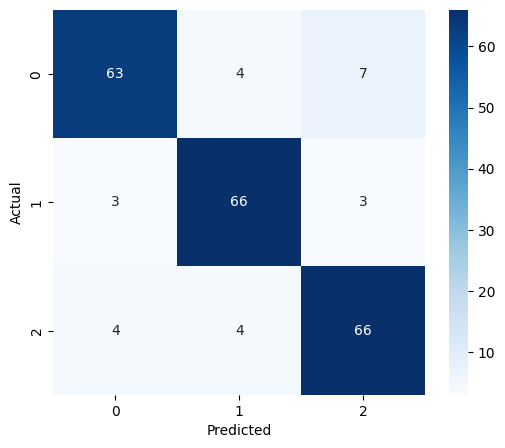

In [15]:
# CONFUSION MATRIX --

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

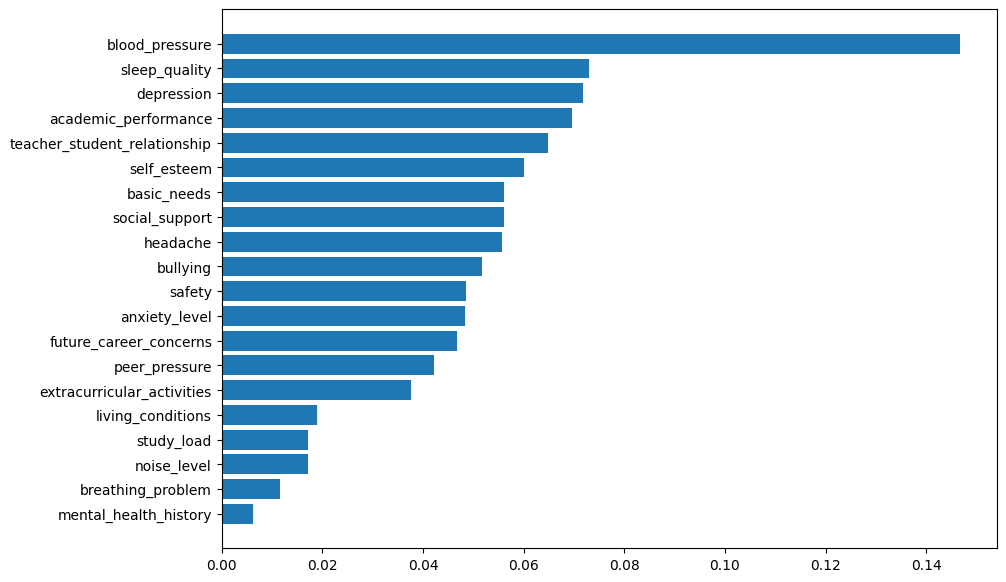

In [16]:
# IMPORTANCE --

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf.feature_importances_
})

importance = (

    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance.head(20)




# VISUALISE IMPORTANCE--

plt.figure(
    figsize=(10,7)
)

plt.barh(

    importance["Feature"],

    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.show()

In [17]:
# SAVING MODEL --

MODEL_DIR = (
    Path.cwd().parent /
    "models"
)

MODEL_DIR.mkdir(
    exist_ok=True
)

In [18]:
# SAVING RANDOM FOREST --

joblib.dump(

    rf,

    MODEL_DIR /
    "stress_model_final.pkl"
)

['c:\\Users\\mohit\\OneDrive\\Desktop\\Calmify AI\\Calmify_AI\\Calmify_AI\\notebooks\\models\\stress_model_final.pkl']

In [19]:
# SAVEING FEATURE NAME --

joblib.dump(

    list(X.columns),

    MODEL_DIR /
    "stress_features.pkl"
)

['c:\\Users\\mohit\\OneDrive\\Desktop\\Calmify AI\\Calmify_AI\\Calmify_AI\\notebooks\\models\\stress_features.pkl']

In [20]:
import os

print(

    os.listdir(
        MODEL_DIR
    )
)

['stress_dataset_best_model.pkl', 'stress_dataset_feature_columns.pkl', 'stress_dataset_label_encoder.pkl', 'stress_features.pkl', 'stress_model_final.pkl', 'student_survey_stress_model.pkl', 'wellness_features.pkl', 'wellness_model_final.pkl']


Stress Level Prediction Model

Algorithm:
Random Forest Classifier

Accuracy:
88.64%

Features:
20

Classes:
0 = Low Stress
1 = Moderate Stress
2 = High Stress

Status:
Production Ready